In [1]:
import numpy as np
import seaborn as sns
from scipy.integrate import solve_ivp

%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt


def g_exponential(x, r=0.2):
    """constant growth rate -> exponential growth"""
    return r


def g_logistic(x, r=0.2, k=10.0):
    """growth rate shrinks linearly as x approaches carrying capacity k"""
    return r * (1 - x / k)


def g_gompertz(x, r=0.2, k=10.0):
    """growth rate shrinks logarithmically as x approaches carrying capacity k"""
    return r * np.log(k / x)


def simulate_growth(g_func, c0=0.1, t_span=(0, 50), n_points=200, **g_kwargs):
    """solve dC/dt = g(x(t)) * C for a given growth-rate function g"""
    def rhs(t, c):
        return g_func(c, **g_kwargs) * c

    t_eval = np.linspace(*t_span, n_points)
    sol = solve_ivp(rhs, t_span, [c0], t_eval=t_eval)
    return sol.t, sol.y[0]

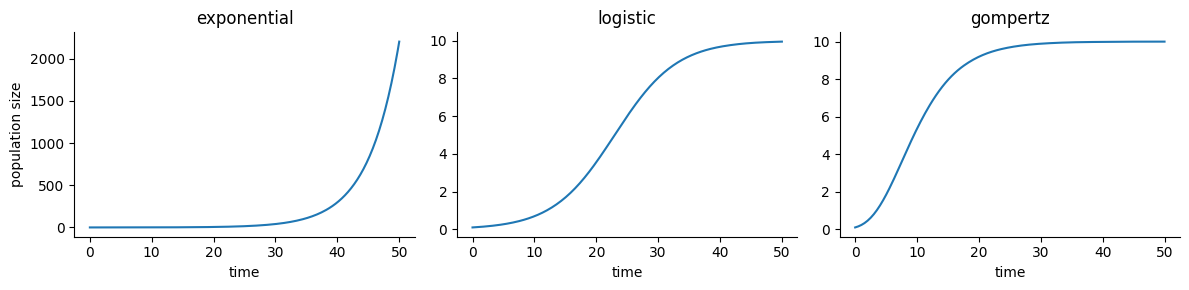

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharex=True)

t_exp, c_exp = simulate_growth(g_exponential, c0=0.1)
t_log, c_log = simulate_growth(g_logistic, c0=0.1)
t_gom, c_gom = simulate_growth(g_gompertz, c0=0.1)

axes[0].plot(t_exp, c_exp)
axes[0].set_title("exponential")

axes[1].plot(t_log, c_log)
axes[1].set_title("logistic")
axes[2].plot(t_gom, c_gom)
axes[2].set_title("gompertz")

for ax in axes:
    ax.set_xlabel("time")
    sns.despine(ax=ax)

axes[0].set_ylabel("population size")

plt.tight_layout()
plt.show()